# 06 Commong Design Building Blocks
- Adding new activation functions
- Inserting new layers to improve training
- Skipping layers as a useful design pattern
- Combining new activations, layers and skips into new approaches
## Creating a baseline with the FashionMINST dataset for the improvements comparisons

In [2]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

In [3]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = False  # False is better for RNNs with variable input sizes, True for CNNs

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')

 dl_utils loaded
Device available: cuda


/home/efrain/Documents/Bio-AI-foundations/DL_utils_EZA/dl_utils.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
# Load the Fashion-MNIST dataset
train_fmnist_data = torchvision.datasets.FashionMNIST("./data", train=True, transform=transforms.ToTensor(), download=False)
test_fmnist_data = torchvision.datasets.FashionMNIST("./data", train=False, transform=transforms.ToTensor(), download=False)

In [4]:
# Data loaders
train_fmnist_loader = DataLoader(train_fmnist_data, 
                                 batch_size=128, 
                                 shuffle=True,
                                 num_workers=4,
                                 pin_memory=True,
                                 persistent_workers=True,
                                 drop_last=True
)

test_fmnist_loader = DataLoader(test_fmnist_data, 
                                batch_size=128*2,
                                shuffle=False,
                                num_workers=4,
                                persistent_workers=True,
                                pin_memory=True
)

In [5]:
# Define the Hyperparameters for the baseline model
W = 28          # Width of the images from FashionMNIST
H = 28          # Height of the images from FashionMNIST
D = 28*28       # Number of values in the input. This value helps to determine size of subsequent layers: 28*28 images
n = 256         # Hidden layers size
C = 1           # Channels in the input
n_filters = 32  # Number of filters (kernels) per convolutional layer
classes = 10    # Number of clases in the data set

loss_function = nn.CrossEntropyLoss()

In [6]:
# Define a FULLY CONNECTED NETWORK baseline model
fc_model_base = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n), # First hidden layer
    nn.Tanh(),
    *[nn.Sequential(nn.Linear(n, n), nn.Tanh()) for _ in range(5)],  # "list unpacking", each reamining layer has the same
                                                                     # input/output sizes.
    nn.Linear(n, classes)
)

In [13]:
# Define the CNN baseline model
cnn_model_base = nn.Sequential(
    nn.Conv2d(C, n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(n_filters,2*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(2*n_filters,4*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(4*n_filters,4*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [ ]:
# Train the Fully Connected Network baseline
fc_model_base_results = train_network_EZA(fc_model_base,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 100/100 [05:09<00:00,  3.09s/it]


In [14]:
# Train the CNN baseline

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

# Train the Fully Connected Network baseline
cnn_model_base_results = train_network_EZA(cnn_model_base,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 30/30 [02:05<00:00,  4.18s/it]


(0.0, 30.0)

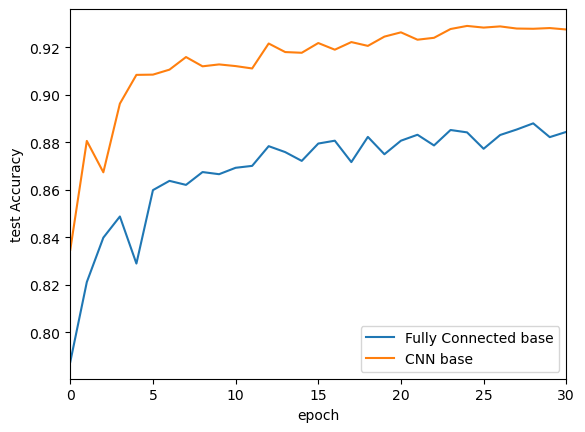

In [17]:
# 
# Plot the results for comparison
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_base_results, label='Fully Connected base')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_base_results, label='CNN base')
plt.xlim(0,30)

## Better Activation Functions
### Vanishing gradients problem of Tanh and sigmoid
When the gradient function gives values close to 0, giving no learing

<Axes: >

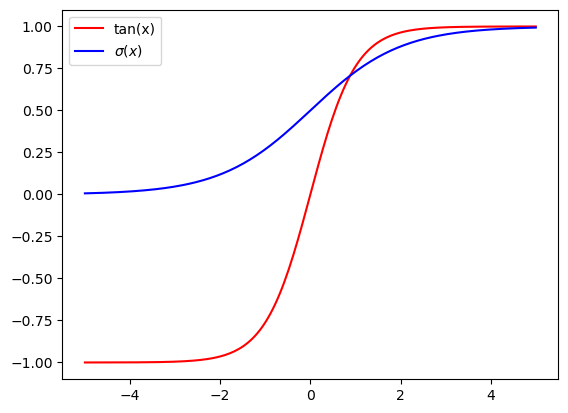

In [20]:
# Plot the sigmoid and Tanh functions
def sigmoid(x):
    return np.exp(activation_input)/(np.exp(activation_input)+1)

activation_input =  np.linspace(-5, 5, num=200)
tanh_activation = np.tanh(activation_input)
sigmoid_activation = sigmoid(activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label='$\sigma(x)$')

<Axes: >

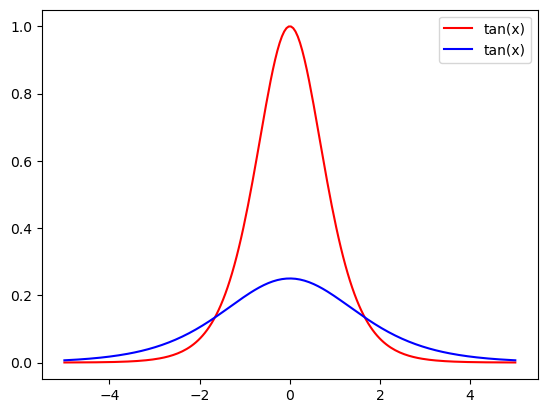

In [ ]:
# Plot the derivatives of the Tanh and sigmoid fucntions to see the saturation effect
def tanh_deriv(x):
    return 1.0 - np.tanh(x)**2
def sigmoid_deriv(x):
    return sigmoid(x)*(1-sigmoid(x))

tanh_deriv = tanh_deriv(activation_input)
sigmoid_deriv = sigmoid_deriv(activation_input)

sns.lineplot(x=activation_input, y=tanh_deriv, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label='sigmoid(x)')

### Avoiding Vanishing Gradients with: Rectified Linear Units (ReLU)
Definition:    $ReLU(x) = max(0,x)$\
Derivative: $ReLU'(x) = 1, if x > 0; 0, otherwise$

Another ReLU variation takes a factor alpha to avoid inactivation\
Definition:   $LeakyReLU(x) = max(\alpha*x,x)$\
Derivative:   $LeakyRELU'(x) = 1, if x > 0;  \alpha$, otherwise

(-1.2, 1.2)

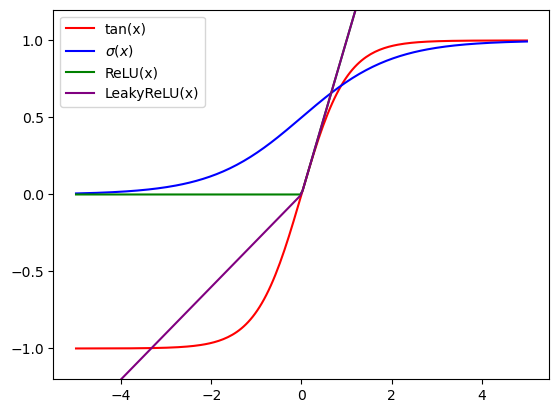

In [29]:
# ReLU and LeakyReLU plots
def leaky_relu(x, alpha=0.1):
    return max(alpha*x, x)
def leaky_reluP(x, alpha=0.1):
    if x > 0:
        return 1
    else:
        return alpha
    
relu_act = np.maximum(0, activation_input)
leaky_relu_act = np.maximum(0.3*activation_input, activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label='$\sigma(x)$')
sns.lineplot(x=activation_input, y=relu_act, color='green', label='ReLU(x)')
sns.lineplot(x=activation_input, y=leaky_relu_act, color='purple', label='LeakyReLU(x)')
plt.ylim(-1.2, 1.2)

<Axes: >

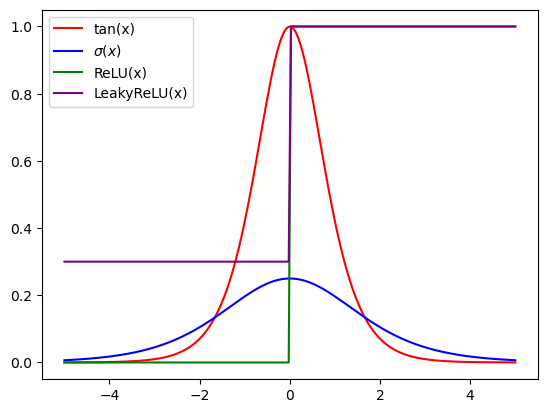

In [30]:
# Plot derivatives
relu_deriv = 1.0*(activation_input >0)
leaky_deriv = 1.0*(activation_input > 0) + 0.3*(activation_input <=0)

sns.lineplot(x=activation_input, y=tanh_deriv, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label='$\sigma(x)$')
sns.lineplot(x=activation_input, y=relu_deriv, color='green', label='ReLU(x)')
sns.lineplot(x=activation_input, y=leaky_deriv, color='purple', label='LeakyReLU(x)')

### Training with LeakyReLU activation

In [28]:
# Define the leak value
leak_rate = 0.1

# Define a FULLY CONNECTED NETWORK with LeakyReLU
fc_model_ReLU = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n), # First hidden layer
    nn.LeakyReLU(),
    *[nn.Sequential(nn.Linear(n, n), nn.LeakyReLU()) for _ in range(5)],  # "list unpacking", each reamining layer has the same
                                                                     # input/output sizes.
    nn.Linear(n, classes)
)

For THE CNN model we define a `cnnLayer` function ot croeate combinations of `Conv2d` to make changes easier

In [32]:
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    """ 
    in_filters: Number of channels going into the layer
    out_filters: Number of channels this layer should learn / ouptut, or "None" if we want the same number of channels as the input
    kernel_size: Size of the kernel
    """
    if out_filters is None:
        out_filters = in_filters  # A common pattern, now automated
    padding = kernel_size//2  # Padding to stay the same size
    return nn.Sequential(
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.LeakyReLU(leak_rate)
    ) 

In [15]:
# Create the CNN model with LeakyReLU
cnn_model_ReLU = nn.Sequential(
    nn.Conv2d(C, n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(n_filters,2*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(2*n_filters,4*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(4*n_filters,4*n_filters, 3, padding=1),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [ ]:
# Train the fully connected network with reLU
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = False  # False for training FC

fc_model_ReLU_results = train_network_EZA(fc_model_ReLU,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

In [16]:
# Train the CNN with ReLU

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

# Train the Fully Connected Network baseline
cnn_model_ReLU_results = train_network_EZA(cnn_model_ReLU,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 30/30 [02:03<00:00,  4.12s/it]


(0.0, 10.0)

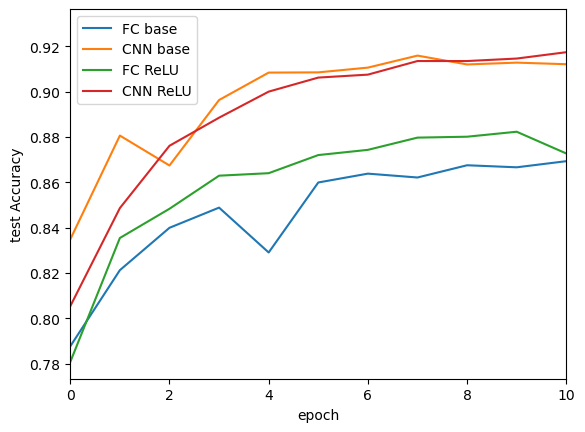

In [ ]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_base_results, label='FC base')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_base_results, label='CNN base')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_ReLU_results, label='FC ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
plt.xlim(0,30)


Try different batch sizes !!!!

## Normalization  layers: Better convergence
Before training the model it is a good practice to normalize the data. Many algorithms are sensitive to the scale of the input data.\
Also, it is better to normalize before every layer of the neural network.
There are two normalization layers widely use:
- batch
- layer
### Batch Normalization (BN)
It normalizes over the data features in a given **batch**

In [7]:
# Define the leak value
leak_rate = 0.1

# Batch normalization model
fc_bn_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.BatchNorm1d(n),
    nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n, n), nn.BatchNorm1d(n), nn.LeakyReLU(leak_rate)) for _ in range(5)],
    nn.Linear(n, classes)
)

In [17]:
# Define a CNN with a function for the model
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    """ 
    in_filters: Number of channels going into the layer
    out_filters: Number of channels this layer should learn / ouptut, or "None" if we want the same number of channels as the input
    kernel_size: Size of the kernel
    """
    if out_filters is None:
        out_filters = in_filters  # A common pattern, now automated
    padding = kernel_size//2  # Padding to stay the same size
    return nn.Sequential(
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.BatchNorm2d(out_filters),
        nn.LeakyReLU(leak_rate)
    ) 

In [18]:
# CNN batch normalization model
cnn_bn_model = nn.Sequential(
    cnnLayer(C, n_filters),
    cnnLayer(n_filters),
    cnnLayer(n_filters),
    nn.MaxPool2d((2, 2)),
    cnnLayer(n_filters, 2*n_filters),
    cnnLayer(2*n_filters),
    cnnLayer(2*n_filters),
    nn.MaxPool2d((2, 2)),
    cnnLayer(2*n_filters, 4*n_filters),
    cnnLayer(4*n_filters),
    cnnLayer(4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [12]:
# Train the fully connected with BN model
torch.backends.cudnn.benchmark = False  # False for training FC

fc_bn_model_results = train_network_EZA(fc_bn_model,
                                        loss_function,
                                        train_fmnist_loader,
                                        test_loader=test_fmnist_loader,
                                        epochs=30,
                                        score_funcs={'Accuracy': accuracy_score},
                                        device=device
)

Epoch: 100%|██████████| 30/30 [02:01<00:00,  4.04s/it]


In [19]:
# Train the CNN with BN

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

cnn_bn_model_results = train_network_EZA(cnn_bn_model,
                        loss_function,
                        train_fmnist_loader,
                        test_loader=test_fmnist_loader,
                        epochs=30,
                        score_funcs={'Accuracy': accuracy_score},
                        device=device
)

Epoch: 100%|██████████| 30/30 [03:08<00:00,  6.30s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

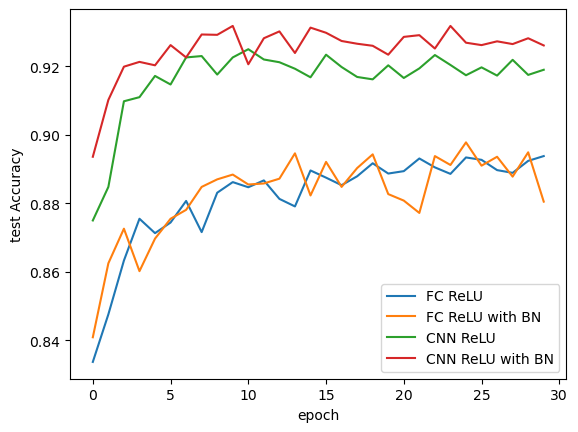

In [23]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_ReLU_results, label='FC ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_model_results, label='FC ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_model_results, label='CNN ReLU with BN')


### Layer Normalization
Takes the average activation over features instead of over batches.

In [32]:
# The Layer Normalized model

fc_ln_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.LayerNorm([n]),
    nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n, n), nn.LayerNorm([n]), nn.LeakyReLU(leak_rate)) for _ in range(5)],
    nn.Linear(n, classes)
)

In [25]:
# CNN layer normalization
# Define a CNN with a function for the model
def cnnLayer2(in_filters, out_filters=None, pool_factor=0,  kernel_size=3):
    """ 
    in_filters: Number of channels going into the layer
    out_filters: Number of channels this layer should learn / ouptut, or "None" if we want the same number of channels as the input
    kernel_size: Size of the kernel
    """
    if out_filters is None:
        out_filters = in_filters  # A common pattern, now automated
    padding = kernel_size//2  # Padding to stay the same size
    return nn.Sequential(  # Combines the layer and activation into a single unit
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.LayerNorm([out_filters, W//(2**pool_factor), H//(2**pool_factor)]),
        nn.LeakyReLU(leak_rate)
    ) 

In [30]:
# CNN layer normalization model
cnn_ln_model = nn.Sequential(
    cnnLayer2(C, n_filters),
    cnnLayer2(n_filters),
    cnnLayer2(n_filters),
    nn.MaxPool2d((2, 2)),
    cnnLayer2(n_filters, 2*n_filters, pool_factor=1),  # After 1 round pool_factor = 1
    cnnLayer2(2*n_filters, pool_factor=1),
    cnnLayer2(2*n_filters, pool_factor=1),
    nn.MaxPool2d((2, 2)),
    cnnLayer2(2*n_filters, 4*n_filters, pool_factor=2),   # After 2 rounds pool_factor = 2
    cnnLayer2(4*n_filters, pool_factor=2),
    cnnLayer2(4*n_filters, pool_factor=2),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [33]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

# Train the fully connected with LN model
torch.backends.cudnn.benchmark = False  # False for training FC

fc_ln_model_results = train_network_EZA(fc_ln_model,
                                        loss_function,
                                        train_fmnist_loader,
                                        test_loader=test_fmnist_loader,
                                        epochs=30,
                                        score_funcs={'Accuracy': accuracy_score},
                                        device=device
)

Epoch: 100%|██████████| 30/30 [01:52<00:00,  3.76s/it]


In [ ]:
# Train the CNN with LN
 
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

cnn_ln_model_results = train_network_EZA(cnn_ln_model,
                        loss_function,
                        train_fmnist_loader,
                        test_loader=test_fmnist_loader,
                        epochs=30,
                        score_funcs={'Accuracy': accuracy_score},
                        device=device
)

Epoch: 100%|██████████| 30/30 [02:32<00:00,  5.08s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

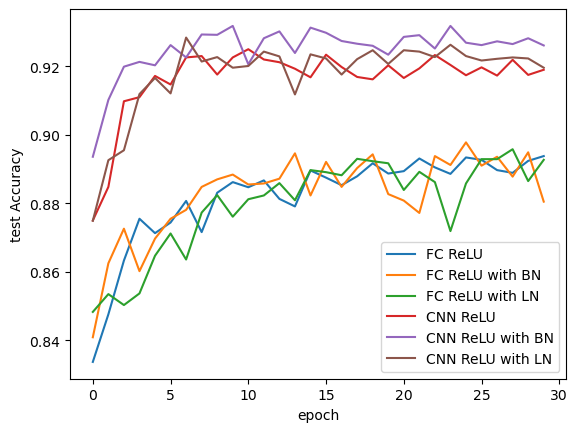

In [35]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_ReLU_results, label='FC ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_model_results, label='FC ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_ln_model_results, label='FC ReLU with LN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_model_results, label='CNN ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_ln_model_results, label='CNN ReLU with LN')

## Skip connections: A network design pattern
To create a skip connection network we define a `SkipFC` Module using a `ModuleList` class using single `.parameters()`.
### Implementing FC skips

In [6]:
# Define the skip connection class

class SkipFC(nn.Module):
    def __init__(self, n_layers, in_size, out_size, leak_rate=0.1):
        """ 
        n_layers: how many hidden layers for this block of dense skip connections
        in_size:  how many features are coming into this layer
        out_size: how many features should be used for the final layer of this block.
        leak_rate: the parameter for the LeakyReLU activation
        """
        super().__init__()   
        l = n_layers-1       # The final layer will be treated differently, so we use its index for the next 2 lines.
        self.layers = nn.ModuleList([
            nn.Linear(in_size*l, out_size) if i == l
            else nn.Linear(in_size, in_size) for i in range(n_layers)])
        self.bns = nn.ModuleList([
            nn.BatchNorm1d(out_size) if i == l
            else nn.BatchNorm1d(in_size) for i in range (n_layers)])
        self.activation = nn.LeakyReLU(leak_rate)   # we can use one activation object multiple times if not using nn.Sequential

    def forward(self, x):
        activations =[]   # The location to stroe the activations from every layer except the last one in this block fir the skips
        for layer, bn in zip(self.layers[:-1], self.bns[:-1]):  # zips the linear and normalization layers into paired tuples wiouth last
            x = self.activation(bn(layer(x)))
            activations.append(x)
            x = torch.cat(activations, dim=1)
            return self.activation(self.bns[-1](self.layers[-1](x)))

In [7]:
# Define the model for the skip connection using the SipFC class and nn.Sequential
fc_skip_model = nn.Sequential(
    nn.Flatten(),
    SkipFC(2, D, n),
    SkipFC(2, n, n),
    SkipFC(2, n, n),
    nn.Linear(n, classes)
)

In [8]:
# Train the skip network

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = False  # False for training FC

fc_skip_results = train_network_EZA(fc_skip_model,
                                    loss_function,
                                    train_fmnist_loader,
                                    test_loader=test_fmnist_loader,
                                    epochs=30,
                                    score_funcs={'Accuracy': accuracy_score},
)

Epoch: 100%|██████████| 30/30 [04:15<00:00,  8.53s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

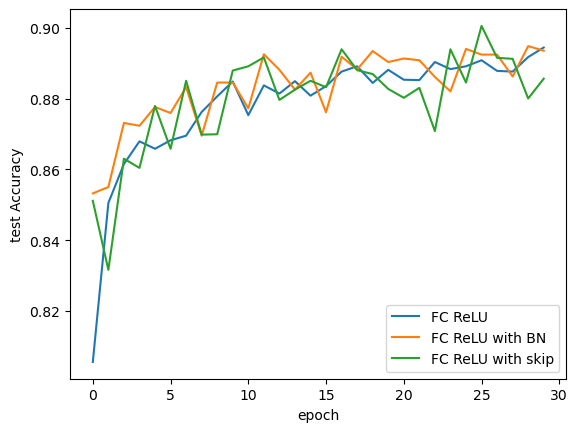

In [13]:
# plot the results and compare
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_ReLU_results, label='FC ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_model_results, label='FC ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_skip_results, label='FC ReLU with skip')


### Implementing Convolutional Skips

In [22]:
# Define the skip convolution class

class SkipConv2d(nn.Module):
    def __init__(self, n_layers, in_channels, out_channels, kernel_size=3, leak_rate=0.1):
        """ 
        n_layers: how many hidden layers for this block of dense skip connections
        in_channels: number of channels in the CNN
        out_channels: for the final layer
        kernel_size: size of the filter 
        leak_rate: the parameter for the LeakyReLU activation
        """
        super().__init__()   
        l = n_layers-1       # The final layer will be treated differently, so we use its index for the next 2 lines.
        f = (kernel_size, kernel_size)   # simple helper values
        pad = (kernel_size-1)//2
        self.layers = nn.ModuleList([
            nn.Conv2d(in_channels*l, out_channels, kernel_size=f, padding=pad) if i == l
            else nn.Conv2d(in_channels, in_channels, kernel_size=f, padding=pad) for i in range(n_layers)])
        self.bns = nn.ModuleList([
            nn.BatchNorm2d(out_channels) if i == l
            else nn.BatchNorm2d(in_channels) for i in range(n_layers)])
        self.activation = nn.LeakyReLU(leak_rate)   # we can use one activation object multiple times if not using nn.Sequential

    def forward(self, x):
        activations =[]   # The location to stroe the activations from every layer except the last one in this block fir the skips
        for layer, bn in zip(self.layers[:-1], self.bns[:-1]):  # zips the linear and normalization layers into paired tuples wiouth last
            x = self.activation(bn(layer(x)))
            activations.append(x)
            x = torch.cat(activations, dim=1)
            return self.activation(self.bns[-1](self.layers[-1](x)))

In [23]:
# CNN with skip model
cnn_skip_model = nn.Sequential(
    nn.Conv2d(C, n_filters, (3,3), padding=1),
    SkipConv2d(3, n_filters, 2*n_filters),
    nn.MaxPool2d((2,2)),
    nn.LeakyReLU(),
    SkipConv2d(3, 2*n_filters, 4*n_filters),
    nn.MaxPool2d((2,2)),
    SkipConv2d(2, 4*n_filters, 4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [ ]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

cnn_skip_results = train_network_EZA(cnn_skip_model,
                        loss_function,
                        train_fmnist_loader,
                        test_loader=test_fmnist_loader,
                        epochs=30,
                        score_funcs={'Accuracy': accuracy_score},
                        device=device
)

In [ ]:
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_model_results, label='CNN ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_skip_results, label='CNN ReLU with Skip')

## 1x1 Convolutions: Sharing and reshaping information in channels
Training 1x1 convolutions with a helper function `infoShareBlock`

In [15]:
# Defining the helper function for the 1x1 convolution
def infoShareBlock(n_filters):
    return nn.Sequential(
        nn.Conv2d(n_filters, n_filters, (1,1), padding=0),
        nn.BatchNorm2d(n_filters),
        nn.LeakyReLU()
    )

In [16]:
# 1x1 CNN model 
cnn_1x1_model = nn.Sequential(
    cnnLayer(C, n_filters),
    cnnLayer(n_filters),
    infoShareBlock(n_filters),
    cnnLayer(n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(n_filters, 2*n_filters),
    cnnLayer(2*n_filters),
    infoShareBlock(2*n_filters),
    cnnLayer(2*n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(2*n_filters, 4*n_filters),
    cnnLayer(4*n_filters),
    infoShareBlock(4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [17]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

cnn_1x1_results = train_network_EZA(cnn_1x1_model,
                        loss_function,
                        train_fmnist_loader,
                        test_loader=test_fmnist_loader,
                        epochs=30,
                        score_funcs={'Accuracy': accuracy_score},
                        device=device
)

Epoch: 100%|██████████| 30/30 [02:48<00:00,  5.62s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

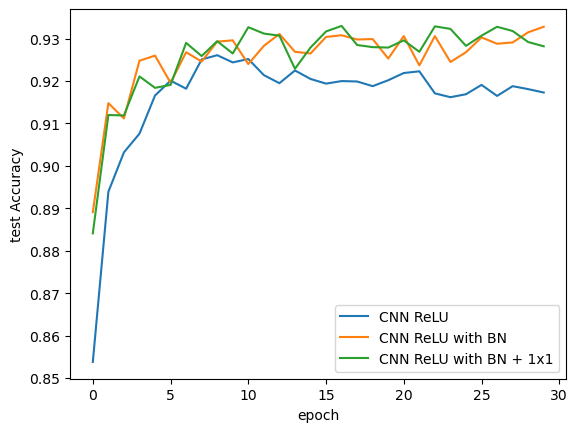

In [32]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_model_results, label='CNN ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_1x1_results, label='CNN ReLU with BN + 1x1')

## Residual Connections
Is the combination of skip connections + 1x1 convolutions.\
They are known as **ResNet-X** with the X refering to the number of layers
### Residual Blocks
Uses a short path and long path.
$$f(x) = x + F(x)$$
Implementing residual block `TypeE`

In [6]:
# Residual block class function
class ResidualBlockE(nn.Module):
    def __init__(self, channels, kernel_size=3, leak_rate=0.1):
    
        """ 
        channels: number of channels in the input/output to this layer
        kerner_size: filter size
        leak_rate: parameter for LeakyReLU
        """
        super().__init__()
        pad = (kernel_size-1)//2  # to maintain the input shape
        self.F = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(leak_rate),
            nn.Conv2d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(leak_rate)
    )
    def forward(self, x):
        return x + self.F(x)   #  F() has all the work fo the long path added to the input

### 

### Residual Bottlenecks

In [7]:
# Residual Bottleneck class function
class ResidualBottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, leak_rate=0.1):
        super().__init__()
        pad = (kernel_size-1)//2   # Maintain input shape
        bottleneck = max(out_channels//4, in_channels)   # 4 times smaller than input.
        self.F = nn.Sequential(
            nn.BatchNorm2d(in_channels),  # Compression
            nn.LeakyReLU(leak_rate),
            nn.Conv2d(in_channels, bottleneck, 1, padding=0),  # 1x1 convolution no padding
            nn.BatchNorm2d(bottleneck),   # Layer with normal convolution
            nn.LeakyReLU(leak_rate),
            nn.Conv2d(bottleneck, bottleneck, kernel_size, padding=pad),
            nn.BatchNorm2d(bottleneck),  # Expands back
            nn.LeakyReLU(leak_rate),
            nn.Conv2d(bottleneck, out_channels, 1, padding=0)
        )
        self.shortcut = nn.Identity() 
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, padding=0),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        return self.shortcut(x) + self.F(x)

In [11]:
leak_rate = 0.1

# Define the residual model
cnn_res_model = nn.Sequential(
    ResidualBottleneck(C, n_filters),
    nn.LeakyReLU(leak_rate),
    ResidualBlockE(n_filters),
    nn.LeakyReLU(leak_rate),
    nn.MaxPool2d((2,2)),
    ResidualBottleneck(n_filters, 2*n_filters),
    nn.LeakyReLU(leak_rate),
    ResidualBlockE(2*n_filters),
    nn.LeakyReLU(leak_rate),
    nn.MaxPool2d((2,2)),
    ResidualBottleneck(2*n_filters, 4*n_filters),
    nn.LeakyReLU(leak_rate),
    ResidualBlockE(4*n_filters),
    nn.LeakyReLU(leak_rate),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [12]:
# Train the cnn with residual blocks and bottlenecks
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

cnn_res_results = train_network_EZA(cnn_res_model,
                        loss_function,
                        train_fmnist_loader,
                        test_loader=test_fmnist_loader,
                        epochs=30,
                        score_funcs={'Accuracy': accuracy_score},
                        device=device
)

Epoch: 100%|██████████| 30/30 [03:31<00:00,  7.05s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

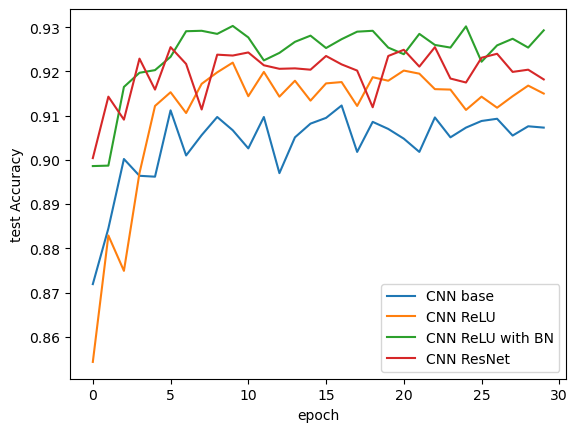

In [24]:
# Plot results and compare
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_base_results, label='CNN base')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_model_results, label='CNN ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_res_results, label='CNN ResNet')


## Long Short-Term Memory RNNs
They create a hidden state $h_{t}$ and context state $C_{t}$.\
$h_{t}$ focuses on the *short-term* information and the $C_{t}$ in the *long-term* information.
### The gating mechanism
Produces a gate value $[0,1]$. It has 3 gates:
- **Forget gate:** forgets the context $C_{t}$
- **input gate:** controls what to add into $C_{t}$
- **output gate:** how much of context $C_{t}$ is included in the final output $h_{t}$.

In [1]:
# Download and locate the data
zip_file_url = 'https://download.pytorch.org/tutorial/data.zip'
import requests, zipfile, io

r = requests.get(zip_file_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

In [4]:
# Code to prepare the dataset
namge_language_data ={}
import unicodedata     # Remove UNICODE tokens to make life easier
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)
alphabet = {}
for i in range(n_letters):
    alphabet[all_letters[i]] = i

def unicodeToAscii(s):        # Turns Unicode string into plain ASCII
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters 
    )

for zip_path in z.namelist():               # Loops through every language, opens the zip file and reads the lines
    if "data/names/" in zip_path and zip_path.endswith(".txt"):
        lang = zip_path[len("data/names/"):-len(".txt")]
        with z.open(zip_path) as myfile:
            lang_names = [unicodeToAscii(line).lower() for line in str(myfile.read(), encoding='utf-8').strip().split("\n")]
            namge_language_data[lang] = lang_names
        print(lang, ": ", len(lang_names))  # prints out the name of each language

Arabic :  2000
Chinese :  268
Czech :  519
Dutch :  297
English :  3668
French :  277
German :  724
Greek :  203
Irish :  232
Italian :  709
Japanese :  991
Korean :  94
Polish :  139
Portuguese :  74
Russian :  9408
Scottish :  100
Spanish :  298
Vietnamese :  73


In [5]:
# We use the LanguageNameDataset from RNNs 

class LanguageNameDataset(Dataset):
    """ 
    The data list contains each name and an associates index in the labels list indicates which language the name came from. 
    A vocabulary dictionary maps every unique item to an integer
    """
    def __init__(self, lang_name_dict, vocabulary):
        self.label_names = [x for x in lang_name_dict.keys()]
        self.data = []
        self.labels = []
        self.vocabulary = vocabulary
        for y, language in enumerate(self.label_names):
            for sample in lang_name_dict[language]:
                self.data.append(self.string2InputVec(sample))
                self.labels.append(y)

    def __len__(self):
        return len(self.data)
    def string2InputVec(self, input_string):
        """ 
        This method will convert any input string into a vector of long values,
        according to the vocabulary used by this object.
        input_string: the string to convert to a tensor
        """
        T = len(input_string)   # the characteres lenght of the string
        name_vec = torch.zeros((T), dtype=torch.long) # Creates a new tensor to store the result
        for pos, character in enumerate(input_string):   # Iterates through the string and places the appropriate values in tensor
            name_vec[pos] = self.vocabulary[character]
        return name_vec
    def __getitem__(self, index):
        return self.data[index], self.labels[index]
    

from torch.nn.utils.rnn import pad_sequence

def pad_collate_fn(batch):
    """
    batch: list of (name_tensor, label) tuples from __getitem__
    Each name_tensor has a different length T.
    We pad all name tensors to the length of the longest one in the batch.
    """
    sequences, labels = zip(*batch)  # unzip into two separate tuples
    
    # pad_sequence stacks and pads: list of (T,) → (T_max, B)
    # batch_first=True reshapes to (B, T_max) which is what nn.RNN expects
    sequences_padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.tensor(labels, dtype=torch.long)
    
    return sequences_padded, labels

In [6]:
# Create a new dataset to determine the language of a given name with 300 items in the split
dataset = LanguageNameDataset(namge_language_data, alphabet)
train_data, test_data = torch.utils.data.random_split(dataset, (len(dataset)-300, 300))
train_loader = DataLoader(train_data,
                          batch_size=32, 
                          shuffle=True, 
                          num_workers=4, 
                          pin_memory=True,   # Critical for eGPU
                          persistent_workers=True,
                          drop_last=False,
                          collate_fn=pad_collate_fn
)
test_loader = DataLoader(test_data,
                         batch_size=32,
                         shuffle=False,
                         num_workers=4,
                         pin_memory=True,   # Critical for eGPU
                         persistent_workers=True,
                         collate_fn=pad_collate_fn
)

In [7]:
class EmbeddingPackable(nn.Module):
    """
    The embedding layer in PyTorch does not support Packed Sequence objects. 
    This wrapper class will fix that. If a normal input comes in, it will 
    use the regular Embedding layer. Otherwise, it will work on the packed 
    sequence to return a new Packed sequence of the appropriate result. 
    """
    def __init__(self, embd_layer):
        super(EmbeddingPackable, self).__init__()
        self.embd_layer = embd_layer 
    
    def forward(self, input):
        if type(input) == torch.nn.utils.rnn.PackedSequence:
            # We need to unpack the input, 
            sequences, lengths = torch.nn.utils.rnn.pad_packed_sequence(input.cpu(), batch_first=True)
            #Embed it
            sequences = self.embd_layer(sequences.to(input.data.device))
            #And pack it into a new sequence
            return torch.nn.utils.rnn.pack_padded_sequence(sequences, lengths.cpu(), 
                                                           batch_first=True, enforce_sorted=False)
        else:#apply to normal data
            return self.embd_layer(input)

In [ ]:
# LastTimeStep hT function
class LastTimeStep(nn.Module):
    """ 
    A class for extracting the hiden activations of the last time 
    step following the output of a Pytorch RNN module.
    """
    def __init__(self, rnn_layers=1, bidirectional=False):
        super(LastTimeStep, self).__init__()
        self.rnn_layers = rnn_layers
        if bidirectional:
            self.num_directions = 2
        else:
            self.num_directions = 1

    def forward(self, input):
        rnn_output = input[0]   # REsults in either a tuple (out, ht) or a tubpel (out, (ht,ct))
        last_step = input[1]   # This is the ht unless it's a tuple
        if(type(last_step) == tuple):
            last_step = last_step[0]

        batch_size = last_step.shape[1]  # Per the docs, shape is (num_layers*num_directions, batch, hiden_size)
        last_step = last_step.view(self.rnn_layers, self.num_directions, batch_size, -1) # Reshapes so everything is separated
        last_step = last_step[self.rnn_layers-1] # We want the last layer's result
        last_step = last_step.permute(1,0,2) # Reorders so the batch comes first
        last_step = last_step.reshape(batch_size, -1)  # flattens the last two dimensions into one
        return last_step

In [ ]:
# RNN model unidirectional
n=256
loss_function = nn.CrossEntropyLoss()

rnn_3layer = nn.Sequential(
    EmbeddingPackable(
        nn.Embedding(len(all_letters), 64)),
        nn.RNN(64, n, num_layers=3, batch_first=True),
        LastTimeStep(rnn_layers=3),
        nn.Linear(n, len(namge_language_data))
)

for p in rnn_3layer.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -5, 5))

In [14]:
# train the model
rnn_results = train_network_EZA(
                        rnn_3layer,
                        loss_function,
                        train_loader,
                        test_loader=test_loader,
                        epochs=20,
                        score_funcs={'Accuracy': accuracy_score},
                        device=device
)

Epoch: 100%|██████████| 20/20 [01:12<00:00,  3.64s/it]


In [15]:
# LSTM model
lstm_3layer = nn.Sequential(
    EmbeddingPackable(
        nn.Embedding(len(all_letters), 64)),
        nn.LSTM(64, n, num_layers=3, batch_first=True),
        LastTimeStep(rnn_layers=3),
        nn.Linear(n, len(namge_language_data))
)

for p in lstm_3layer.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -5, 5))

In [16]:
# train the model
lstm_results = train_network_EZA(
                        lstm_3layer,
                        loss_function,
                        train_loader,
                        test_loader=test_loader,
                        epochs=20,
                        score_funcs={'Accuracy': accuracy_score},
                        device=device
)

Epoch: 100%|██████████| 20/20 [01:53<00:00,  5.69s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

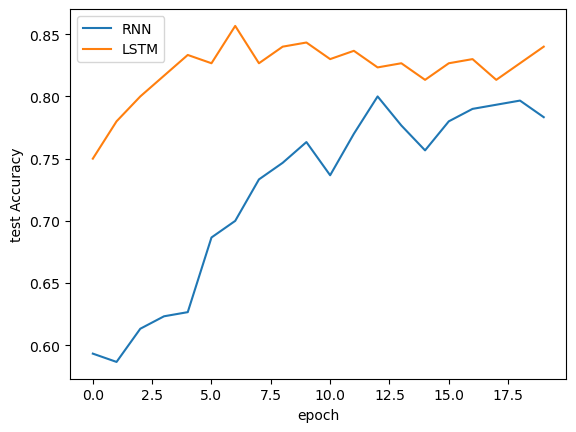

In [17]:
# Plot the results
sns.lineplot(x='epoch', y='test Accuracy', data=rnn_results, label='RNN')
sns.lineplot(x='epoch', y='test Accuracy', data=lstm_results, label='LSTM')
